Rellenar datos faltantes con el body o title? Rellenar ciudades y adress con latitud y longitud? dividir por barrio? como usamos latitud y longitud para todo eso? nos interesa la fecha? hasta lo que tengo de conocimeinto lo que mas influye en el precio es la zona, el metro cuadrado en puntac arretas es mas elevado que en pocitos, despues los cuarts, baños (como los completo)?
Barrio separar latitud y longitud y usar distancia y mediana, usar zip para barrios.
Hacer correlacion y si hay muchas que estan altamente relacionadas usar PCA para achicar variables que usamos.

In [377]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

In [378]:
df = pd.read_csv('Resources/Tema_9.csv',encoding='latin1', delimiter=';')

In [379]:
print(f"\nDimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print("\n Primeras 5 filas:")
df.head(10)




Dimensiones del dataset: 10000 filas x 22 columnas

 Primeras 5 filas:


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401
5,5667891676,housing/rent/apartment,0 BR in New York NY 10019,**RARE GEM WITH PRIVATE OUTDOOR TERRACE****AVA...,"Dishwasher,Elevator,Patio/Deck,Pool,Storage",1.0,0.0,USD,No,Thumbnail,...,"$2,475",Monthly,130,350 West 50th St,Manhattan,NY,40.7629,-73.9885,Listanza,1577289784
6,5668627426,housing/rent/apartment,Studio apartment 2432 Penmar Ave,"This unit is located at 2432 Penmar Ave, Venic...",NaN,NaN,0.0,USD,No,Thumbnail,...,"$1,800",Monthly,132,2432 Penmar Avenue,Venice,CA,33.9932,-118.4609,RentLingo,1577359461
7,5668626687,housing/rent/apartment,"Studio apartment Oak St NW, 16th St NW, Washin...","This unit is located at Oak St NW, 16th St NW,...",NaN,NaN,0.0,USD,No,Thumbnail,...,$840,Monthly,136,NaN,Washington,DC,38.9328,-77.0297,RentLingo,1577359393
8,5668610290,housing/rent/apartment,Studio apartment 333 Hyde St,"This unit is located at 333 Hyde St, San Franc...",Refrigerator,1.0,0.0,USD,No,Thumbnail,...,"$1,495",Monthly,138,333 Hyde St,San Francisco,CA,37.7599,-122.4379,RentLingo,1577358313
9,5668627023,housing/rent/apartment,"Studio apartment A St SE, 19th St SE, Washington","This unit is located at A St SE, 19th St SE, W...",NaN,NaN,0.0,USD,No,Thumbnail,...,$890,Monthly,141,NaN,Washington,DC,38.9118,-77.0132,RentLingo,1577359424


Para el precio vamos a usar price en vez de price_display.

In [380]:
print("\n Últimas 5 filas:")
df.tail()


 Últimas 5 filas:


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
9995,5630240092,housing/rent/apartment,Five BR 5407 Abbott Place - Abbott,This unit is located at 5407 Abbott Place - Ab...,NaN,4.0,5.0,USD,No,Thumbnail,...,"$6,000",Monthly,6300,5407 Abbott Place Abbott,Edina,MN,44.9000,-93.3233,RentLingo,1575112975
9996,5668640983,housing/rent/apartment,Six BR 256 Las Entradas,"This unit is located at 256 Las Entradas, Mont...",NaN,8.0,6.0,USD,No,Thumbnail,...,"$25,000",Monthly,8716,256 Las Entradas,Montecito,CA,34.4331,-119.6331,RentLingo,1577360419
9997,5668643292,housing/rent/apartment,Six BR 9908 Bentcross Drive,"This unit is located at 9908 Bentcross Drive, ...",NaN,8.5,6.0,USD,No,Thumbnail,...,"$11,000",Monthly,11318,9908 Bentcross Dr,Potomac,MD,39.0287,-77.2409,RentLingo,1577360560
9998,5668662559,housing/rent/apartment,One BR in New York NY 10069,"Monthly Rent$4,605 -to $4,790AmenitiesThe Aldy...","Basketball,Cable or Satellite,Doorman,Hot Tub,...",NaN,1.0,USD,No,Thumbnail,...,"$4,790",Monthly,40000,NaN,New York,NY,40.7716,-73.9876,Listanza,1577362186
9999,5509132540,housing/rent/apartment,Beautiful Lawrenceville Apartment for rent,"Square footage: 880 sq. feet, unit number: 150...","Gym,Patio/Deck",1.0,1.0,USD,No,No,...,"$1,009",Monthly,880,NaN,Lawrenceville,GA,34.0072,-84.0034,RentDigs.com,1577362141


In [381]:
print("\nInformación de columnas:")
print(df.info())

print("\nTipos de datos por columna:")
print(df.dtypes)




Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-n

In [382]:
print("\nEstadísticas descriptivas (variables númericas):")
df.describe()


Estadísticas descriptivas (variables númericas):


,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,1.000000e+04,9966.000000,9993.000000,10000.000000,10000.000000,9990.000000,9990.000000,1.000000e+04
mean,5.623396e+09,1.380544,1.744021,1486.277500,945.810500,37.695162,-94.652247,1.574891e+09
std,7.021025e+07,0.615410,0.942354,1076.507968,655.755736,5.495851,15.759805,3.762395e+06
min,5.508654e+09,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
25%,5.509248e+09,1.000000,1.000000,949.000000,649.000000,33.679850,-101.301700,1.568781e+09
50%,5.668610e+09,1.000000,2.000000,1270.000000,802.000000,38.809800,-93.651600,1.577358e+09
75%,5.668626e+09,2.000000,2.000000,1695.000000,1100.000000,41.349800,-82.209975,1.577359e+09
max,5.668663e+09,8.500000,9.000000,52500.000000,40000.000000,61.594000,-70.191600,1.577362e+09


In [383]:
print("\nEstadísticas descriptivas (variables categóricas):")
df.describe(include=['object'])


Estadísticas descriptivas (variables categóricas):


,category,title,body,amenities,currency,fee,has_photo,pets_allowed,price_display,price_type,address,cityname,state,source
count,10000,10000,10000,6451,10000,10000,10000,5837,10000,10000,6673,9923,9923,10000
unique,3,9350,9961,2254,1,1,3,3,1726,3,6658,1574,51,12
top,housing/rent/apartment,Apartment in great location,"When searching for a pet-friendly One-, Two- a...",Parking,USD,No,Thumbnail,"Cats,Dogs","$1,350",Monthly,908 8th SW St,Austin,TX,RentLingo
freq,9996,40,6,229,10000,10000,8907,5228,86,9998,3,523,1737,6912


              Cantidad  Porcentaje
pets_allowed      4163       41.63
amenities         3549       35.49
address           3327       33.27
cityname            77        0.77
state               77        0.77
bathrooms           34        0.34
latitude            10        0.10
longitude           10        0.10
bedrooms             7        0.07


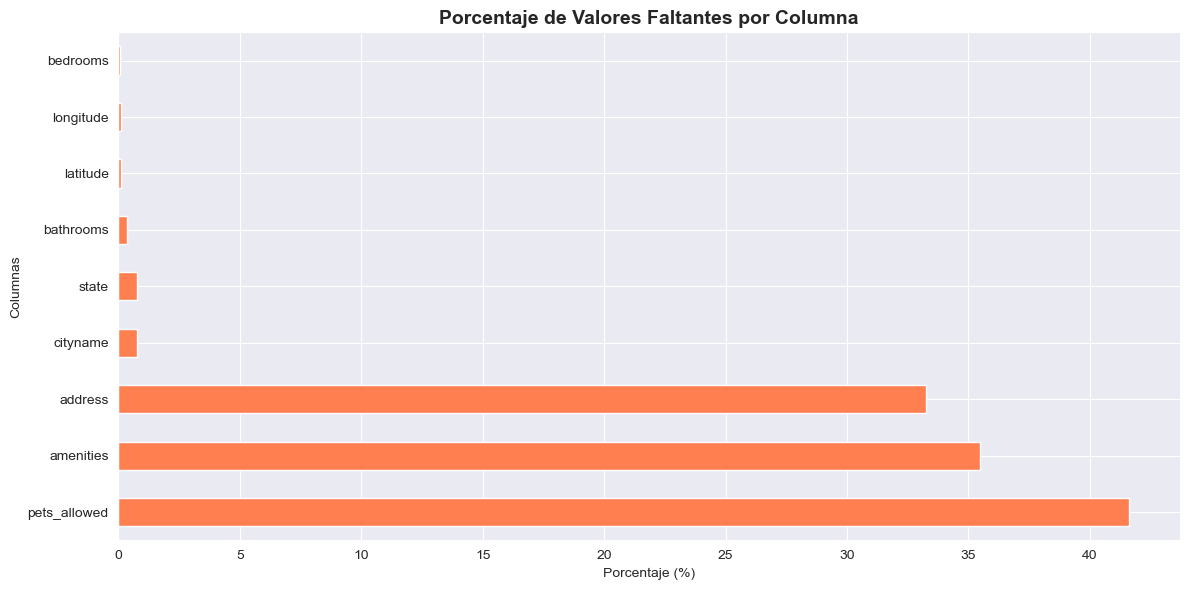

In [384]:
missing_data = pd.DataFrame({
    'Cantidad': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Cantidad'] > 0].sort_values('Cantidad', ascending=False)
print(missing_data)
if not missing_data.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_data['Porcentaje'].plot(kind='barh', color='coral', ax=ax)
    ax.set_title('Porcentaje de Valores Faltantes por Columna', fontsize=14, fontweight='bold')
    ax.set_xlabel('Porcentaje (%)')
    ax.set_ylabel('Columnas')
    plt.tight_layout()
    plt.show()

Dado que son 10000 valores decidimos eliminar las filas que tengan missing values en alguna de las siguientes columnas: bathroom, latitud, longitud, bedrooms. Son pocos registros que no van a aportar y quizas imputarle valores nos perjudique mas de lo que nos puede beneficiar.

In [385]:
columnas= ['bathrooms', 'latitude', 'longitude', 'bedrooms']

# Verificar cuántas filas se van a eliminar
print(f"Registros antes: {len(df)}")
print(f"Registros con nulos en columnas críticas: {df[columnas].isnull().any(axis=1).sum()}")

# Eliminar filas
df = df.dropna(subset=columnas)

print(f"Registros después: {len(df)}")

Registros antes: 10000
Registros con nulos en columnas críticas: 50
Registros después: 9950


In [386]:
print(f"Valores duplicados: {df.duplicated().sum()}")
print(f"Valores unicos por columna: \n{df.nunique().sort_values(ascending=False)}")


Valores duplicados: 0
Valores unicos por columna: 
id               9950
body             9911
title            9301
address          6631
time             6299
latitude         2388
longitude        2386
amenities        2249
square_feet      1725
price_display    1724
price            1723
cityname         1572
state              51
bathrooms          14
source             12
bedrooms           10
category            3
pets_allowed        3
has_photo           3
price_type          2
fee                 1
currency            1
dtype: int64


In [387]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"   • {col}: {unique_count:,}")

    # Mostrar top 5 si tiene sentido
    if 2 < unique_count < 500:
        print(f"      Top 3: {df[col].value_counts().head(3).to_dict()}")


   • category: 3
      Top 3: {'housing/rent/apartment': 9947, 'housing/rent/home': 2, 'housing/rent/short_term': 1}
   • title: 9,301
   • body: 9,911
   • amenities: 2,249
   • currency: 1
   • fee: 1
   • has_photo: 3
      Top 3: {'Thumbnail': 8858, 'Yes': 909, 'No': 183}
   • pets_allowed: 3
      Top 3: {'Cats,Dogs': 5213, 'Cats': 483, 'Dogs': 124}
   • price_display: 1,724
   • price_type: 2
   • address: 6,631
   • cityname: 1,572
   • state: 51
      Top 3: {'TX': 1730, 'CA': 950, 'WA': 519}
   • source: 12
      Top 3: {'RentLingo': 6869, 'RentDigs.com': 2763, 'ListedBuy': 177}


Currency y fee se pueden eliminar, el currency sabemos que es en USD y el fee es el mismo para todos entonces no va a afectar a las predicciones

id: Identificador único sin valor predictivo
category: Solo tiene "housing/rent/apartment" (3 valores de 10000)
currency: 100% USD
fee: 100% "No"
price_display: Duplicado de price
source: No aporta al precio del apartamento
time: Las fechas son todas del 2019, no hay variación temporal útil

In [388]:
df = df.drop(['id', 'category', 'currency', 'fee', 'price_display', 'source', 'time'], axis=1)

In [389]:
df_pets_vacios = df[df['pets_allowed'].isnull()]

# Opción 1: Usar non-capturing group (?:...)
patron = r'\b(?:pet|pets|dog|dogs|cat|cats|mascota|mascotas|perro|gato|animal|animals)\b'

# Opción 2: Sin paréntesis (más simple)
patron = r'\bpet\b|\bpets\b|\bdog\b|\bdogs\b|\bcat\b|\bcats\b|\banimal\b|\banimals\b'

# Encontrar descripciones que mencionan mascotas
menciona_pets = df_pets_vacios[
    df_pets_vacios['body'].str.contains(patron, case=False, na=False, regex=True)
]

# Ver los resultados
print(f"Total con pets_allowed nulo: {len(df_pets_vacios)}")
print(f"De esos, mencionan mascotas: {len(menciona_pets)}")
menciona_pets['body']
solo_dog = menciona_pets[
    menciona_pets['body'].str.contains(r'\bdog\b|\bdogs\b', case=False, na=False, regex=True)
]

solo_cat = menciona_pets[
    menciona_pets['body'].str.contains(r'\bcat\b|\bcats\b', case=False, na=False, regex=True)
]

solo_pets = menciona_pets[
    menciona_pets['body'].str.contains(r'\bpet\b|\bpets\b', case=False, na=False, regex=True)
]

# Ver resultados
print(f"Mencionan 'dog/dogs': {len(solo_dog)}")
print(f"Mencionan 'cat/cats': {len(solo_cat)}")
print(f"Mencionan 'pet/pets': {len(solo_pets)}")
#Con esta info completaremos algunos de los missing values, los que no se completen con estos valores se le imputara el valor Unknown. Se les imputara el valor 0 a los que sean unknown y 1 a los que permitan algun tipo de mascota.

Total con pets_allowed nulo: 4130
De esos, mencionan mascotas: 876
Mencionan 'dog/dogs': 243
Mencionan 'cat/cats': 119
Mencionan 'pet/pets': 777


In [390]:
# ver los valores que mas aparecen en los ammenities y buscarlos en el body para completar valores faltantes


In [391]:
print("\n Estadísticas del Precio:")
print(f"   • Media: ${df['price'].mean():,.2f}")
print(f"   • Mediana: ${df['price'].median():,.2f}")
print(f"   • Desv. Estándar: ${df['price'].std():,.2f}")
print(f"   • Mínimo: ${df['price'].min():,.2f}")
print(f"   • Máximo: ${df['price'].max():,.2f}")
print(f"   • Rango: ${df['price'].max() - df['price'].min():,.2f}")
print(f"   • CV (Coef. Variación): {(df['price'].std() / df['price'].mean()) * 100:.2f}%")


 Estadísticas del Precio:
   • Media: $1,487.59
   • Mediana: $1,275.00
   • Desv. Estándar: $1,077.35
   • Mínimo: $200.00
   • Máximo: $52,500.00
   • Rango: $52,300.00
   • CV (Coef. Variación): 72.42%


In [392]:
#Deteccion de outliers
#Metodo IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
outliers_iqr = df[(df['price'] < lower_iqr) | (df['price'] > upper_iqr)]
print(f"      • Límite inferior: ${lower_iqr:,.2f}")
print(f"      • Límite superior: ${upper_iqr:,.2f}")
print(f"      • Outliers detectados: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")

      • Límite inferior: $-167.50
      • Límite superior: $2,812.50
      • Outliers detectados: 614 (6.17%)


In [393]:
#Metodo de Z-score
z_scores = np.abs(stats.zscore(df['price']))
outliers_zscore = df[z_scores > 3]
print(f"      • Outliers detectados: {len(outliers_zscore)} ({len(outliers_zscore)/len(df)*100:.2f}%)")


      • Outliers detectados: 122 (1.23%)


In [394]:
#Metodo de percentiles
outliers_percentile = df[(df['price'] < df['price'].quantile(0.01)) |
                         (df['price'] > df['price'].quantile(0.99))]
print(f"      • Outliers detectados: {len(outliers_percentile)} ({len(outliers_percentile)/len(df)*100:.2f}%)")

      • Outliers detectados: 194 (1.95%)


In [395]:
# Top y bottom precios
print("\n TOP 10 PRECIOS MÁS ALTOS:")
print(df.nlargest(10, 'price')[['price', 'bedrooms', 'bathrooms', 'square_feet', 'cityname', 'state']])

print("\n TOP 10 PRECIOS MÁS BAJOS:")
print(df.nsmallest(10, 'price')[['price', 'bedrooms', 'bathrooms', 'square_feet', 'cityname', 'state']])



 TOP 10 PRECIOS MÁS ALTOS:
      price  bedrooms  bathrooms  square_feet     cityname state
8829  52500       0.0        1.0         1418      Barstow    CA
9996  25000       6.0        8.0         8716    Montecito    CA
9990  19500       4.0        5.0         5000  Los Angeles    CA
9972  14950       6.0        4.0         4044  Los Angeles    CA
8581  13500       2.0        2.0         1325  Los Angeles    CA
9825  13000       3.0        3.0         2530  Los Angeles    CA
8573  11000       2.0        2.0         1322     Coronado    CA
9946  11000       5.0        1.0         3395    Hollywood    FL
9997  11000       6.0        8.5        11318      Potomac    MD
9227  10600       2.0        2.0         1636  Los Angeles    CA

 TOP 10 PRECIOS MÁS BAJOS:
      price  bedrooms  bathrooms  square_feet       cityname state
181     200       1.0        1.0          250     Mount Airy    MD
1751    224       1.0        1.0          587        Decatur    IN
4435    288       1.0       

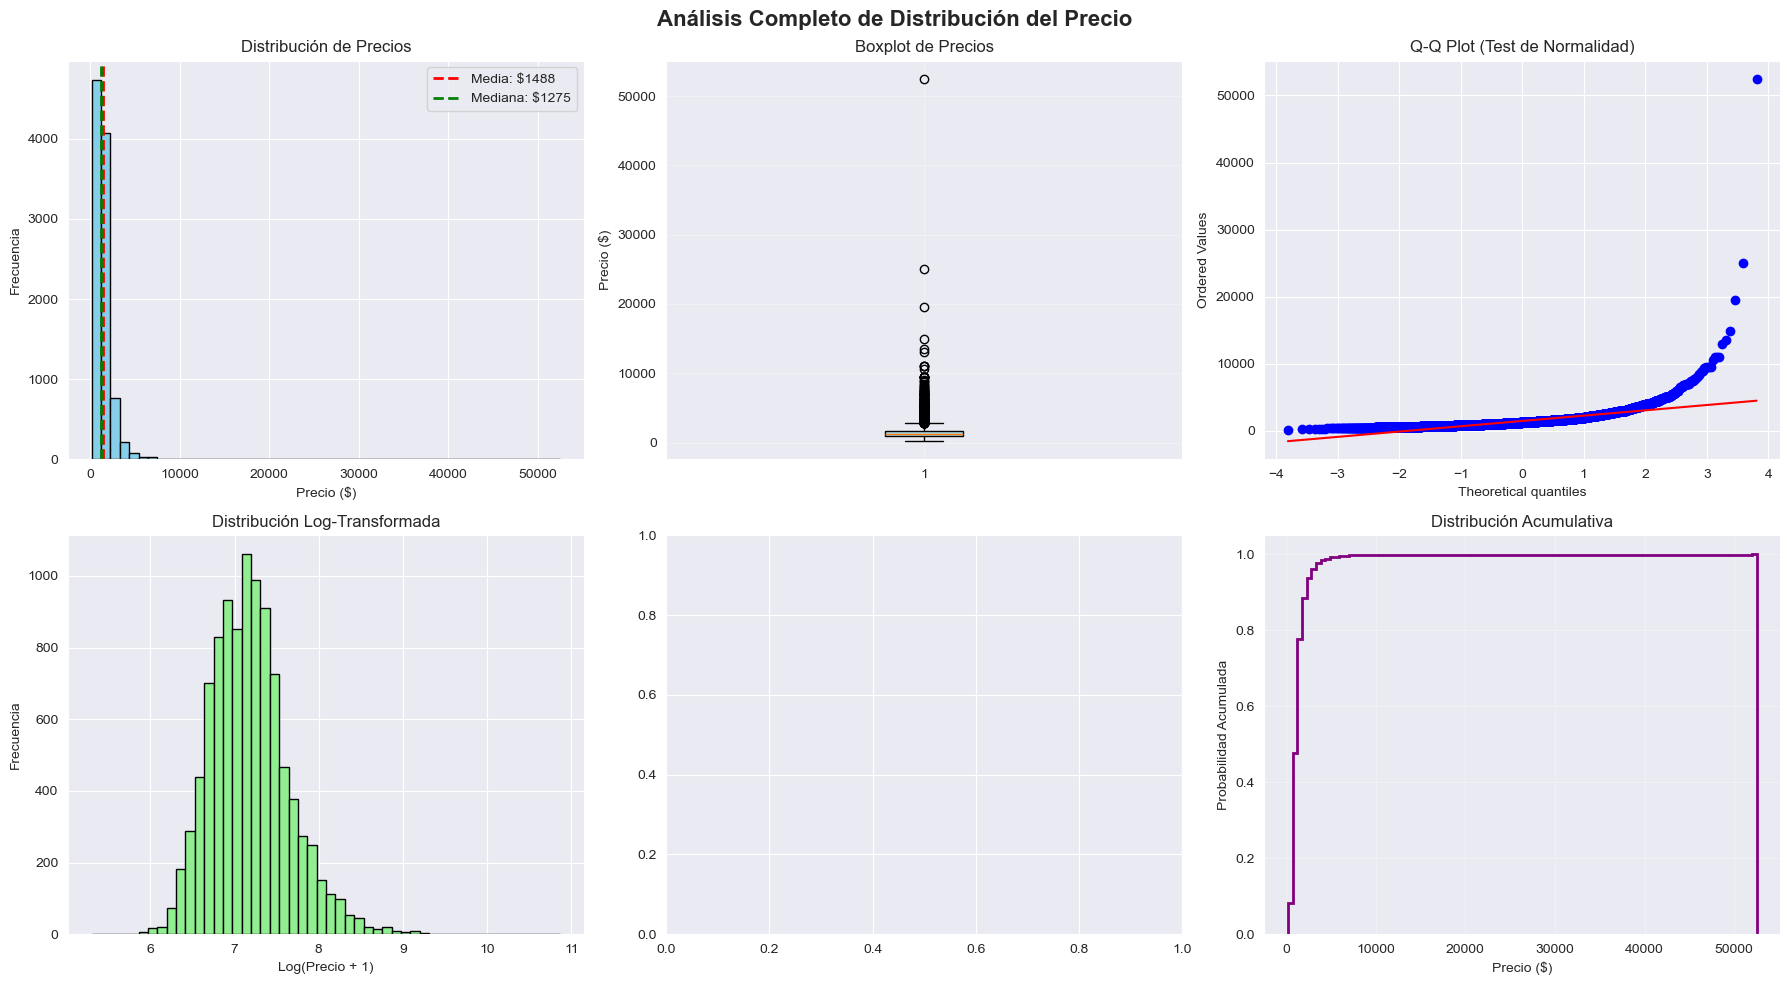

In [396]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análisis Completo de Distribución del Precio', fontsize=16, fontweight='bold')

# 1. Histograma
axes[0, 0].hist(df['price'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].axvline(df['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${df["price"].mean():.0f}')
axes[0, 0].axvline(df['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: ${df["price"].median():.0f}')
axes[0, 0].set_title('Distribución de Precios')
axes[0, 0].set_xlabel('Precio ($)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

# 2. Boxplot
bp = axes[0, 1].boxplot(df['price'].dropna(), vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[0, 1].set_title('Boxplot de Precios')
axes[0, 1].set_ylabel('Precio ($)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot
stats.probplot(df['price'].dropna(), dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot (Test de Normalidad)')

# 4. Log transformation
axes[1, 0].hist(np.log1p(df['price']), bins=50, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribución Log-Transformada')
axes[1, 0].set_xlabel('Log(Precio + 1)')
axes[1, 0].set_ylabel('Frecuencia')


# 6. Cumulative distribution
axes[1, 2].hist(df['price'], bins=100, cumulative=True, density=True,
                histtype='step', linewidth=2, color='purple')
axes[1, 2].set_title('Distribución Acumulativa')
axes[1, 2].set_xlabel('Precio ($)')
axes[1, 2].set_ylabel('Probabilidad Acumulada')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [397]:
import re
patron_si = r'''
    \b(?:
        (?:pet|pets|dog|dogs|cat|cats|animals?)\s*(?:allowed|welcome|friendly|ok|permitted|accepted|negotiable)|
        (?:dog|cat|pet)\s*friendly|
        accepts?\s*(?:pet|dog|cat)s?|
        (?:pet|dog|cat)s?\s*(?:are\s*)?(?:welcome|ok|allowed)|
        with\s*(?:pet|dog|cat)s?
    )\b
'''

# Patrones para "NO permite mascotas"
patron_no = r'''
    \b(?:
        no\s*(?:pet|dog|cat|animal)s?|
        (?:pet|dog|cat|animal)s?\s*(?:not\s*allowed|prohibited|restricted|banned)|
        (?:pet|dog|cat|animal)\s*free|
        without\s*(?:pet|dog|cat)s?|
        (?:pet|dog|cat)s?\s*not\s*permitted
    )\b
'''

# Compilar patrones (case-insensitive, verbose para permitir comentarios)
regex_si = re.compile(patron_si, re.IGNORECASE | re.VERBOSE)
regex_no = re.compile(patron_no, re.IGNORECASE | re.VERBOSE)

def clasificar_pets_desde_body(body):
    """
    Clasifica la política de mascotas basándose en el texto de body.

    Returns:
        'Yes': Si permite mascotas explícitamente
        'No': Si NO permite mascotas explícitamente
        'Unknown': Si no se menciona o no es claro
    """
    if pd.isna(body) or body == '':
        return 'Unknown'

    body_lower = str(body).lower()

    # Buscar primero patrones negativos (más específicos)
    if regex_no.search(body_lower):
        return 'No'

    # Luego buscar patrones positivos
    if regex_si.search(body_lower):
        return 'Yes'

    # No menciona o no es claro
    return 'Unknown'

# Aplicar clasificación solo a valores nulos
print(f"\n   🔍 Analizando {df['pets_allowed'].isnull().sum()} registros con 'body' para inferir política de mascotas...")

nulls_mask = df['pets_allowed'].isnull()
df.loc[nulls_mask, 'pets_allowed'] = df.loc[nulls_mask, 'body'].apply(clasificar_pets_desde_body)


   🔍 Analizando 4130 registros con 'body' para inferir política de mascotas...


In [398]:
# Normalizar valores existentes primero
df['pets_allowed'] = df['pets_allowed'].fillna('Unknown').astype(str).str.strip().str.title()

# Mapping para conversión numérica
# 1 = Permite mascotas (Cats, Dogs, Yes, o combinaciones)
# 0 = No permite o Unknown

def pets_to_numeric(value):
    """
    Convierte pets_allowed a numérico:
    1 = Permite mascotas
    0 = No permite o desconocido
    """
    if pd.isna(value):
        return 0

    value_str = str(value).lower()

    # Considera como "permite mascotas" si menciona cats, dogs o yes
    if any(pet in value_str for pet in ['cat', 'dog', 'yes']):
        return 1
    else:
        return 0


# SOBRESCRIBIR la columna original con valores numéricos
df['pets_allowed'] = df['pets_allowed'].apply(pets_to_numeric)


df['has_photo'] = df['has_photo'].map({
    'Thumbnail': 1,
    'Photo': 2,
    'No': 0
})

Extraccion de amenities.

In [399]:
import re
from collections import Counter

def analyze_existing_amenities(df):
    """
    Analiza qué amenities son más comunes en el dataset
    """
    print("="*70)
    print("ANÁLISIS DE AMENITIES EXISTENTES")
    print("="*70)

    # Extraer todas las amenities
    all_amenities = []
    for amenities_str in df['amenities'].dropna():
        # Split por coma y limpiar espacios
        items = [a.strip() for a in str(amenities_str).split(',')]
        all_amenities.extend(items)

    # Contar frecuencias
    amenities_count = Counter(all_amenities)

    print(f"\n📈 Top 20 Amenities más comunes:\n")
    for amenity, count in amenities_count.most_common(20):
        pct = count / len(df.dropna(subset=['amenities'])) * 100
        print(f"   {amenity:30s} → {count:4d} veces ({pct:5.1f}%)")

    return amenities_count

# Ejecutar análisis
amenities_count = analyze_existing_amenities(df)

ANÁLISIS DE AMENITIES EXISTENTES

📈 Top 20 Amenities más comunes:

   Parking                        → 3725 veces ( 57.8%)
   Dishwasher                     → 3264 veces ( 50.7%)
   Pool                           → 3231 veces ( 50.2%)
   Refrigerator                   → 3129 veces ( 48.6%)
   Patio/Deck                     → 2472 veces ( 38.4%)
   Cable or Satellite             → 1674 veces ( 26.0%)
   Storage                        → 1529 veces ( 23.7%)
   Gym                            → 1469 veces ( 22.8%)
   Internet Access                → 1440 veces ( 22.4%)
   Clubhouse                      → 1317 veces ( 20.4%)
   Garbage Disposal               → 1209 veces ( 18.8%)
   Washer Dryer                   → 1076 veces ( 16.7%)
   Fireplace                      → 1065 veces ( 16.5%)
   Playground                     →  781 veces ( 12.1%)
   AC                             →  660 veces ( 10.2%)
   Elevator                       →  641 veces ( 10.0%)
   Tennis                         →  

In [400]:
def complete_amenities_from_body(df):
    """
    Completa amenities faltantes buscando en el body.
    Usa patrones positivos Y negativos para evitar falsos positivos.
    """

    print("\n" + "="*70)
    print("COMPLETANDO AMENITIES DESDE BODY")
    print("="*70)

    df = df.copy()

    # Definir patrones basados en las amenities más comunes
    # Cada amenity tiene:
    # - 'positive': patrones que indican presencia
    # - 'negative': patrones que indican ausencia (para descartar)

    amenity_patterns = {
        'Parking': {
            'positive': r'\b(parking|garage|covered parking|assigned parking|parking space|parking available)\b',
            'negative': r'\b(no parking|without parking|parking not included|street parking only)\b'
        },
        'Furnished':{'positive':r'\b(Furnished)\b', 'negative':r'\b(no furnished)\b'},
        'Laundry': {
            'positive': r'\b(laundry|washer|dryer|in-unit laundry|washer\/dryer|w\/d|laundry in unit)\b',
            'negative': r'\b(no laundry|without laundry|shared laundry|coin laundry)\b'
        },
        'Air Conditioning': {
            'positive': r'\b(air conditioning|a\/c|ac|central air|cooling|climate control)\b',
            'negative': r'\b(no ac|no air conditioning|window units only)\b'
        },
        'Dishwasher': {
            'positive': r'\bdishwasher\b',
            'negative': r'\b(no dishwasher|without dishwasher)\b'
        },
        'Pool': {
            'positive': r'\b(pool|swimming pool|community pool)\b',
            'negative': r'\b(no pool|pool access not included)\b'
        },
        'Gym': {
            'positive': r'\b(gym|fitness center|fitness room|exercise room|workout room)\b',
            'negative': r'\b(no gym|no fitness)\b'
        },
        'Balcony': {
            'positive': r'\b(balcony|patio|deck|terrace|outdoor space)\b',
            'negative': r'\b(no balcony|no patio|no outdoor)\b'
        },
        'Elevator': {
            'positive': r'\belevator\b',
            'negative': r'\b(no elevator|walk-?up|stairs only)\b'
        },
        'Hardwood': {
            'positive': r'\b(hardwood|wood floor|hardwood floor)\b',
            'negative': r'\b(no hardwood|carpet|tile only)\b'
        },
        'Pet Friendly': {
            'positive': r'\b(pet friendly|pets allowed|pet-friendly|dogs allowed|cats allowed)\b',
            'negative': r'\b(no pets|pets not allowed|no animals)\b'
        },
        'Storage': {
            'positive': r'\b(storage|storage unit|extra storage|storage space)\b',
            'negative': r'\b(no storage|limited storage)\b'
        },
        'Refrigerator': {
            'positive': r'\b(refrigerator|fridge|stainless appliances)\b',
            'negative': r'\b(no refrigerator|no fridge)\b'
        }
    }

    # Contar registros a procesar
    mask_empty = df['amenities'].isna()
    total_to_process = mask_empty.sum()

    print(f"\n🔍 Registros con amenities vacíos: {total_to_process}")
    print(f"🔍 Registros con amenities completos: {(~mask_empty).sum()}\n")

    # Estadísticas
    stats = {
        'total_processed': 0,
        'filled': 0,
        'by_amenity': {amenity: 0 for amenity in amenity_patterns.keys()}
    }

    # Procesar cada registro con amenities vacío
    for idx in df[mask_empty].index:
        body = df.at[idx, 'body']

        if pd.isna(body) or body == '':
            continue

        body_lower = str(body).lower()
        found_amenities = []

        # Buscar cada amenity
        for amenity, patterns in amenity_patterns.items():
            # Buscar patrón positivo
            if re.search(patterns['positive'], body_lower, re.IGNORECASE):
                # Verificar que NO haya patrón negativo
                if not re.search(patterns['negative'], body_lower, re.IGNORECASE):
                    found_amenities.append(amenity)
                    stats['by_amenity'][amenity] += 1

        # Si se encontraron amenities, guardar
        if found_amenities:
            df.at[idx, 'amenities'] = ','.join(found_amenities)
            stats['filled'] += 1

        stats['total_processed'] += 1

    # Mostrar resultados
    print("="*70)
    print("RESULTADOS")
    print("="*70)
    print(f"\n✓ Registros procesados: {stats['total_processed']}")
    print(f"✓ Registros completados: {stats['filled']} ({stats['filled']/total_to_process*100:.1f}%)")
    print(f"\n📊 Amenities encontradas por tipo:\n")

    for amenity, count in sorted(stats['by_amenity'].items(),
                                  key=lambda x: x[1], reverse=True):
        if count > 0:
            print(f"   {amenity:20s} → {count:4d} veces")

    # Verificar estado final
    print(f"\n📈 Estado final de la columna 'amenities':")
    print(f"   Completos: {df['amenities'].notna().sum()} ({df['amenities'].notna().sum()/len(df)*100:.1f}%)")
    print(f"   Vacíos: {df['amenities'].isna().sum()} ({df['amenities'].isna().sum()/len(df)*100:.1f}%)")

    return df, stats

# Aplicar
df, completion_stats = complete_amenities_from_body(df)


COMPLETANDO AMENITIES DESDE BODY

🔍 Registros con amenities vacíos: 3508
🔍 Registros con amenities completos: 6442

RESULTADOS

✓ Registros procesados: 3508
✓ Registros completados: 274 (7.8%)

📊 Amenities encontradas por tipo:

   Furnished            →  100 veces
   Laundry              →   80 veces
   Pet Friendly         →   42 veces
   Parking              →   31 veces
   Balcony              →   29 veces
   Refrigerator         →   11 veces
   Air Conditioning     →    9 veces
   Hardwood             →    3 veces
   Pool                 →    2 veces
   Dishwasher           →    1 veces
   Storage              →    1 veces

📈 Estado final de la columna 'amenities':
   Completos: 6716 (67.5%)
   Vacíos: 3234 (32.5%)


In [401]:
df_amenities_vacios = df[df['amenities'].isnull()]
df_amenities_vacios['body']

2       This unit is located at N Scott St, 14th St N,...
3       This unit is located at 1717 12th Ave, Seattle...
18      This unit is located at 545 Georgia street 717...
24      This unit is located at Herons Path Pl, Riverv...
33      This unit is located at Ginger Ct, Manassas, 2...
                              ...                        
9992    This unit is located at 17595 Burl Oak Court, ...
9994    This unit is located at 2536 W Canyon Ridge Rd...
9995    This unit is located at 5407 Abbott Place - Ab...
9996    This unit is located at 256 Las Entradas, Mont...
9997    This unit is located at 9908 Bentcross Drive, ...
Name: body, Length: 3234, dtype: object

Queda un tercio vacio, que hacemos?


Para completar ciudad y estados vamos a usar la herramienta geopy para reverse geocoding con latitud y longitud

In [402]:
city_missing = df['cityname'].isnull().sum()
state_missing = df['state'].isnull().sum()

if city_missing > 0 or state_missing > 0:
    print(f"   Registros a procesar: {max(city_missing, state_missing)}")

    try:
        from geopy.geocoders import Nominatim
        from geopy.exc import GeocoderTimedOut, GeocoderServiceError
        import time
    except ImportError:
        print("   ERROR: geopy no instalado. Imputando con moda...")
        if city_missing > 0:
            mode_city = df['cityname'].mode()[0] if not df['cityname'].mode().empty else 'Unknown'
            df['cityname'].fillna(mode_city, inplace=True)
        if state_missing > 0:
            mode_state = df['state'].mode()[0] if not df['state'].mode().empty else 'Unknown'
            df['state'].fillna(mode_state, inplace=True)
    else:
        geolocator = Nominatim(user_agent="apartment_rental_prediction_2025")

        def reverse_geocode(lat, lon, max_retries=3):
            for attempt in range(max_retries):
                try:
                    time.sleep(1.1)
                    location = geolocator.reverse(f"{lat}, {lon}", language='en', timeout=10)

                    if location and location.raw.get('address'):
                        address = location.raw['address']
                        city = (address.get('city') or address.get('town') or
                               address.get('village') or address.get('municipality') or
                               address.get('county'))
                        state = address.get('state')
                        return {'city': city, 'state': state}
                    return None
                except (GeocoderTimedOut, GeocoderServiceError):
                    if attempt < max_retries - 1:
                        time.sleep(2)
                        continue
                    return None
                except:
                    return None
            return None

        needs_geocoding = (df['cityname'].isnull() | df['state'].isnull())
        total_to_process = needs_geocoding.sum()

        geocoded = 0
        failed = 0

        for idx in df[needs_geocoding].index:
            row = df.loc[idx]
            if pd.notna(row['latitude']) and pd.notna(row['longitude']):
                result = reverse_geocode(row['latitude'], row['longitude'])

                if result:
                    if result['city'] and pd.isna(df.at[idx, 'cityname']):
                        df.at[idx, 'cityname'] = result['city']
                    if result['state'] and pd.isna(df.at[idx, 'state']):
                        df.at[idx, 'state'] = result['state']
                    geocoded += 1
                else:
                    failed += 1

                if (geocoded + failed) % 20 == 0:
                    print(f"   Progreso: {geocoded + failed}/{total_to_process}")

        print(f"   Geocoding: {geocoded} exitosos, {failed} fallidos")

        if df['cityname'].isnull().sum() > 0 or df['state'].isnull().sum() > 0:
            if df['cityname'].isnull().sum() > 0:
                mode_city = df['cityname'].mode()[0] if not df['cityname'].mode().empty else 'Unknown'
                df['cityname'].fillna(mode_city, inplace=True)
            if df['state'].isnull().sum() > 0:
                mode_state = df['state'].mode()[0] if not df['state'].mode().empty else 'Unknown'
                df['state'].fillna(mode_state, inplace=True)
else:
    print(f"   No hay valores faltantes")

   Registros a procesar: 67
   Progreso: 20/67
   Progreso: 40/67
   Progreso: 60/67
   Geocoding: 67 exitosos, 0 fallidos


In [403]:
df_adress_vacio = df[df['address'].isnull()]
df_adress_vacio['body']

2       This unit is located at N Scott St, 14th St N,...
15      New Bern Studio includes : 1 beds, 1 microwave...
17      This unit is located at Spring Ridge Dr, Sprin...
19      This unit is located at Falcon Wood Dr, Mariet...
20      This unit is located at Branthurst Dr, Charlot...
                              ...                        
9942    Cable ready, Hard wood floors, Refrigerator, D...
9946    A pristine oceanfront residence at TRUMP HOLLY...
9958    This unit is located at Ward Road - Retreat to...
9963    If you re looking to rent a new home in the Gr...
9999    Square footage: 880 sq. feet, unit number: 150...
Name: body, Length: 3305, dtype: object

# CLUSTERING GEOESPACIAL PARA IDENTIFICACIÓN DE BARRIOS

## ¿Qué es y por qué lo usamos?

**Problema:** El dataset NO tiene información de barrios, pero sabemos que la ubicación
es el de los principales determinantes en el precio de una propiedad. Logramos conseguir las ciudades mediante un API, pensamos conseguir los barrios de la misma manera pero al ser una API gratuita demoraria mucho.La importancia para nosotros del barrio es que por ejemplo el metro cuadrado en el golf punta carretas es mas caro que en malvin.

**Solución:** Usar clustering para identificar barrios automáticamente basándonos en
coordenadas geográficas (latitud y longitud).

**Cluster = Grupo de propiedades geográficamente cercanas con características similares**

---

## ¿Cómo funciona DBSCAN?

**DBSCAN** (Density-Based Spatial Clustering) identifica "zonas densas" de propiedades:

### Parámetros clave:

- **eps (epsilon):** Radio de vecindad en km. Si dos propiedades están a menos de
  `eps` km, son vecinas.
  - `eps=1.5km` ≈ 15 min caminando (tamaño típico de barrio)

- **min_samples:** Mínimo de propiedades para formar un barrio.
  - `min_samples=5` = necesita al menos 5 propiedades cercanas

### Ventajas de DBSCAN:

✅ No requiere especificar número de clusters (se descubren automáticamente)
✅ Detecta outliers (propiedades aisladas)
✅ Captura barrios de forma irregular (no solo círculos)

---

## Estrategia: Clustering Jerárquico

**NO podemos clusterizar todo EEUU junto** porque NYC y LA están a 4,500km
→ nunca serían vecinas pero DBSCAN los vería como "distantes".

**Solución: Dos niveles**

1. **Nivel 1 - Ciudad:** Separar por ciudad
2. **Nivel 2 - Barrio:** Aplicar DBSCAN DENTRO de cada ciudad
```python
Austin, TX (523 propiedades):
   ├─ Cluster 42 (Downtown): 28 props → $2,400/mes promedio
   ├─ Cluster 45 (North): 35 props → $1,650/mes promedio
   ├─ Cluster 47 (East): 41 props → $1,200/mes promedio
   └─ Outliers: 36 props → propiedades aisladas

In [404]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

def create_hierarchical_neighborhood_clusters(df, eps_km=1.5, min_samples=5):
    """
    Crea clusters de barrios usando DBSCAN de forma jerárquica.

    Aplica clustering DENTRO de cada ciudad para identificar barrios.
    Agrega columna 'neighborhood_cluster' al dataframe.

    Parameters:
    -----------
    df : DataFrame
        DataFrame con columnas 'latitude', 'longitude', 'cityname'
    eps_km : float
        Radio en kilómetros para definir vecindad (default: 1.5km)
    min_samples : int
        Mínimo de propiedades para formar un cluster (default: 5)

    Returns:
    --------
    df : DataFrame
        DataFrame con columna 'neighborhood_cluster' agregada
    """

    df = df.copy()

    # Convertir km a grados (1° latitud ≈ 111km)
    eps_degrees = eps_km / 111

    # Inicializar columna de clusters
    df['neighborhood_cluster'] = -1

    # Contador global de cluster ID
    global_cluster_id = 0

    # Procesar cada ciudad independientemente
    for city in df['cityname'].unique():
        if pd.isna(city):
            continue

        # Filtrar propiedades de esta ciudad
        city_mask = df['cityname'] == city
        city_df = df[city_mask]

        if len(city_df) < min_samples:
            continue

        # Coordenadas
        coords = city_df[['latitude', 'longitude']].values

        # DBSCAN
        db = DBSCAN(eps=eps_degrees, min_samples=min_samples, metric='euclidean')
        local_clusters = db.fit_predict(coords)

        # Mapear clusters locales a IDs globales únicos
        cluster_map = {}
        for local_id in set(local_clusters):
            if local_id == -1:
                cluster_map[-1] = -1
            else:
                cluster_map[local_id] = global_cluster_id
                global_cluster_id += 1

        # Asignar clusters globales
        global_clusters = np.array([cluster_map[c] for c in local_clusters])
        df.loc[city_mask, 'neighborhood_cluster'] = global_clusters

    return df


# Ejecutar
df = create_hierarchical_neighborhood_clusters(df, eps_km=1.5, min_samples=5)